In [ ]:
# Figure 2: Context Size Analysis and Layerwise Convergence
#
# This notebook generates two figures relating to the In-Context Learning capabilities
# of the model on the MNIST dataset.
#
# Figure 2A: Test Set RMSE as a function of Context Size (N).
# Figure 2B: Test Set RMSE at intermediate layers for a fixed Context Size (N=100).
#
# Configuration:
# Set FORCE_RETRAIN to True to ignore existing checkpoints and retrain all models.

import os
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader, TensorDataset, random_split, Subset
from torch.optim.lr_scheduler import CosineAnnealingLR
from pathlib import Path

# Configuration
FORCE_RETRAIN = False
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL_DIR = Path('models/figure2')
DATA_ROOT = Path('./data')

# Experiment Hyperparameters
SEEDS = [0, 1, 2]
CONTEXT_SIZES = list(range(50, 501, 50))
FIXED_CONTEXT_FOR_LAYER_PLOT = 100
NOISE_STD = 0.3
EPOCHS = 750
LR = 1e-2
LAYERS = 6


# Ensure model directory exists
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"Running on {DEVICE}")

Running on cuda


In [2]:
# Model Architecture
# Defines the RBF Manifold Attention and the Multi-Step Denoiser. 
# This architecture implements the kernel-weighted update scheme described in 
# Lemma 2 via a self-attention mechanism.

class RBFManifoldAttention(nn.Module):
    def __init__(self):
        super().__init__()

    @staticmethod
    def _pairwise_scores(x, tx, kernel='std'):
        # Calculates interactions between context tokens (Self-Attention).
        
        # squared norms
        x2 = (x**2).sum(-1, keepdim=True)
        
        # pairwise dot-products
        dot = torch.matmul(x, x.transpose(-1, -2))
        
        # pairwise squared distances
        dist2 = -2 * dot
        if kernel == 'rbf':
            dist2 = dist2 + x2 + x2.transpose(-2, -1)
            
        w = torch.softmax(-0.5 * dist2 / tx[None, :, None], dim=-1)
        expX = torch.matmul(w, x)

        return -(x - expX) / tx[None, :, None]

    def forward(self, x, tW, tx, kernel='std'):
        # In Manifold Denoising, we only look at self-interaction (x with x).
        x_score = self._pairwise_scores(x, tx, kernel)
        return x_score

class LStepManifoldDenoiser(nn.Module):
    def __init__(self, L, t_start=1.0, t_end=0.1, kernel='std'):
        super().__init__()

        self.scores = nn.ModuleList([
            RBFManifoldAttention()
            for i in range(L)
        ])
        self.kernel = kernel
        
        # Schedule parameters
        t_lin  = torch.linspace(t_start, t_end, L)
        dt_lin = torch.cat([t_lin[1:] - t_lin[:-1], t_lin[-1:] - t_lin[-2:-1]]) / 2
        
        # Initialize time parameters (broadcastable)
        self.tx_raw  = nn.Parameter(torch.log(torch.exp(t_lin).detach()  - 1)[:, None].repeat((1, 2)).detach())
        self.dtx_raw = nn.Parameter(torch.log(torch.exp(-dt_lin).detach() - 1)[:, None].repeat((1, 2)).detach())

    def times_and_steps(self):
        tx  = F.softplus(self.tx_raw)
        dtx = -F.softplus(self.dtx_raw)
        return tx, dtx

    def forward(self, x0):
        tx, dtx = self.times_and_steps()
        C = x0.shape[1]
        x = x0
        traj = [x.clone()]
        L = len(self.scores)
        
        for i in range(L):
            # We only need time parameters for x (the context)
            dtx_vec = torch.cat((dtx[i, 0].repeat(C - 1), dtx[i, 1].repeat(1))).to(x.device)
            tx_vec = torch.cat((tx[i, 0].repeat(C - 1), tx[i, 1].repeat(1))).to(x.device)

            # Pass dummy tW=None
            x_score = self.scores[i](x, None, tx_vec, self.kernel)
            
            # Update step (Euler discretization of Manifold flow)
            x = x - tx_vec[None, :, None] * dtx_vec[None, :, None] * x_score
            
            traj.append(x.clone())
            
        return x, traj

In [3]:
# Data Loading
# We prepare the MNIST dataset. The models require flattening the 28x28 images 
# into 784-dimensional vectors.

def get_mnist_data():
    transform = T.Compose([T.ToTensor(), T.Lambda(lambda x: x.view(-1))])
    
    # Download and load full training set
    mnist_full = torchvision.datasets.MNIST(DATA_ROOT, train=True, download=True, transform=transform)
    
    # Prepare TensorDataset on GPU for speed
    data_tensor = torch.stack([d[0] for d in mnist_full]).to(DEVICE)
    label_tensor = torch.tensor([d[1] for d in mnist_full], device=DEVICE)
    dataset = TensorDataset(data_tensor, label_tensor)
    
    # 90/10 Train/Test Split
    n_total = len(dataset)
    n_train = int(0.9 * n_total)
    
    train_set, test_set = random_split(
        dataset, [n_train, n_total - n_train],
        generator=torch.Generator().manual_seed(42)
    )
    
    return train_set, test_set

train_set_all, test_set_all = get_mnist_data()
print(f"Data loaded: {len(train_set_all)} training samples, {len(test_set_all)} test samples.")

Data loaded: 54000 training samples, 6000 test samples.


In [4]:
# Helper Functions for Training and Evaluation
# These functions handle the training loop, checkpoint management, and 
# RMSE calculation.

def get_checkpoint_path(context_size, seed, epochs):
    filename = f"mnist_N{context_size}_seed{seed}_L{LAYERS}_ep{epochs}.pth"
    return MODEL_DIR / filename

def train_or_load_model(context_size, seed, train_set, epochs=EPOCHS):
    """
    Trains a model or loads a checkpoint if available.
    Args:
        context_size (int): Number of context examples.
        seed (int): Random seed.
        train_set (Dataset): The training data.
        epochs (int): Number of training epochs. Defaults to global config.
    """
    ckpt_path = get_checkpoint_path(context_size, seed, epochs)
    
    # Initialize model using the Manifold architecture
    model = LStepManifoldDenoiser(
        L=LAYERS, t_start=10, t_end=3, kernel='rbf'
    ).to(DEVICE)
    
    # Check if valid checkpoint exists
    if ckpt_path.exists() and not FORCE_RETRAIN:
        print(f"Loading existing model for N={context_size}, Seed={seed}, Epochs={epochs}...")
        # strict=False is required to ensure compatibility with checkpoints 
        # that may contain unused parameters from previous architecture versions.
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE), strict=False)
        return model

    print(f"Training model for N={context_size}, Seed={seed}, Epochs={epochs}...")
    
    # Training setup
    groups_per_batch = 10
    batch_size = context_size * groups_per_batch
    loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, drop_last=True)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    scaler = torch.cuda.amp.GradScaler()
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs * len(loader), eta_min=1e-3)
    
    model.train()
    
    for epoch in range(epochs):
        for clean_batch, _ in loader:
            # Reshape into [Batch // N, N, D]
            B = clean_batch.shape[0]
            clean = clean_batch.reshape(B // context_size, context_size, -1).to(DEVICE)
            noisy = clean + torch.randn_like(clean) * NOISE_STD
            
            with torch.cuda.amp.autocast(dtype=torch.float16):
                recon, _ = model(noisy)
                # Loss is Mean Squared Error of norms
                loss = ((recon - clean).norm(p=2, dim=2) ** 2).mean()
                
            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            
    # Save checkpoint
    torch.save(model.state_dict(), ckpt_path)
    return model

@torch.no_grad()
def evaluate_rmse(model, test_set, context_size):
    model.eval()
    mse_sum = 0.0
    n_tokens = 0
    
    # Batch size for evaluation
    eval_batch = max(context_size * 5, context_size)
    loader = DataLoader(test_set, batch_size=eval_batch, shuffle=False, drop_last=False)
    
    for clean_batch, _ in loader:
        B = clean_batch.shape[0]
        groups = B // context_size
        
        if groups == 0:
            continue
            
        # Ensure full groups
        clean = clean_batch[:groups * context_size]
        clean = clean.reshape(groups, context_size, -1).to(DEVICE)
        noisy = clean + torch.randn_like(clean) * NOISE_STD
        
        with torch.cuda.amp.autocast(dtype=torch.float16):
            recon, _ = model(noisy)
            mse_sum += ((recon - clean).norm(p=2, dim=2) ** 2).sum().item()
            
        n_tokens += groups * context_size
        
    return math.sqrt(mse_sum / n_tokens)

Starting Experiment 2A: RMSE vs Context Size
Loading existing model for N=50, Seed=0, Epochs=750...
Loading existing model for N=50, Seed=1, Epochs=750...
Loading existing model for N=50, Seed=2, Epochs=750...
Context Size N= 50 | RMSE: 5.3746 ± 0.0003
Loading existing model for N=100, Seed=0, Epochs=750...
Loading existing model for N=100, Seed=1, Epochs=750...
Loading existing model for N=100, Seed=2, Epochs=750...
Context Size N=100 | RMSE: 5.3024 ± 0.0012
Loading existing model for N=150, Seed=0, Epochs=750...
Loading existing model for N=150, Seed=1, Epochs=750...
Loading existing model for N=150, Seed=2, Epochs=750...
Context Size N=150 | RMSE: 5.2717 ± 0.0021
Loading existing model for N=200, Seed=0, Epochs=750...
Loading existing model for N=200, Seed=1, Epochs=750...
Loading existing model for N=200, Seed=2, Epochs=750...
Context Size N=200 | RMSE: 5.2515 ± 0.0025
Loading existing model for N=250, Seed=0, Epochs=750...
Loading existing model for N=250, Seed=1, Epochs=750...
Lo

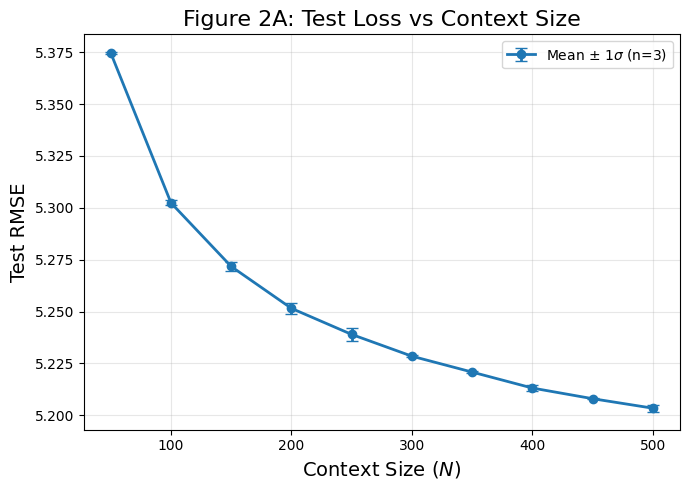

In [5]:
# Experiment 2A: RMSE vs Context Size
# We iterate through defined context sizes and seeds, training (or loading)
# models and computing the final test set RMSE.

results_2a = {
    'context_sizes': CONTEXT_SIZES,
    'means': [],
    'stds': []
}

print("Starting Experiment 2A: RMSE vs Context Size")

for N in CONTEXT_SIZES:
    rmse_runs = []
    for seed in SEEDS:
        # Set seed for reproducibility
        torch.manual_seed(seed)
        
        # Get model
        model = train_or_load_model(N, seed, train_set_all)
        
        # Evaluate
        rmse = evaluate_rmse(model, test_set_all, N)
        rmse_runs.append(rmse)
        
    # Aggregate stats
    mean_rmse = np.mean(rmse_runs)
    std_rmse = np.std(rmse_runs, ddof=1) if len(rmse_runs) > 1 else 0.0
    
    results_2a['means'].append(mean_rmse)
    results_2a['stds'].append(std_rmse)
    
    print(f"Context Size N={N:3d} | RMSE: {mean_rmse:.4f} ± {std_rmse:.4f}")

# Plotting Figure 2A
plt.figure(figsize=(7, 5))
plt.errorbar(
    results_2a['context_sizes'], 
    results_2a['means'], 
    yerr=results_2a['stds'], 
    fmt='-o', 
    capsize=4, 
    linewidth=2, 
    label=f'Mean $\pm$ 1$\sigma$ (n={len(SEEDS)})'
)
plt.xlabel("Context Size ($N$)", fontsize=14)
plt.ylabel("Test RMSE", fontsize=14)
plt.title("Figure 2A: Test Loss vs Context Size", fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Starting Experiment 2B: Layerwise RMSE (N=100, Epochs=50)
Loading existing model for N=100, Seed=0, Epochs=50...
Loading existing model for N=100, Seed=1, Epochs=50...
Loading existing model for N=100, Seed=2, Epochs=50...


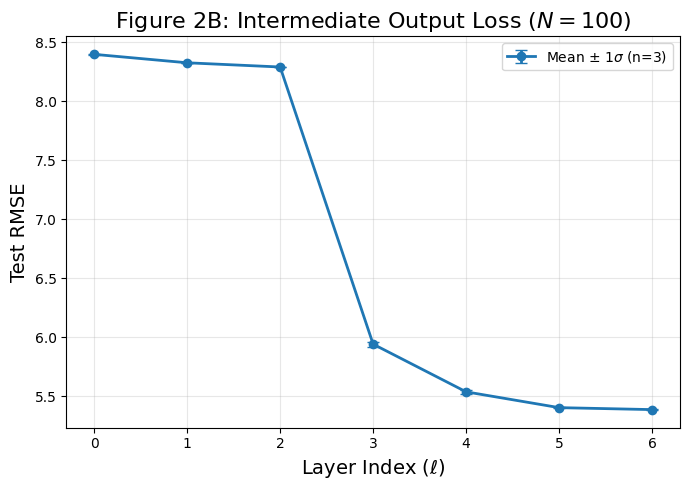

In [9]:
# Experiment 2B: Layerwise RMSE for fixed N=100
# We examine the convergence of the model layer-by-layer.


LAYERWISE_EPOCHS = 50

@torch.no_grad()
def evaluate_layerwise_rmse(model, test_set, context_size):
    model.eval()
    # Initialize sums for each layer (0 to L)
    sum_mse = np.zeros(LAYERS + 1, dtype=np.float64)
    n_tokens = 0
    
    eval_batch = max(context_size * 5, context_size)
    loader = DataLoader(test_set, batch_size=eval_batch, shuffle=False)
    
    for clean_batch, _ in loader:
        B = clean_batch.shape[0]
        groups = B // context_size
        
        if groups == 0:
            continue
            
        clean = clean_batch[:groups * context_size]
        clean = clean.reshape(groups, context_size, -1).to(DEVICE)
        noisy = clean + torch.randn_like(clean) * NOISE_STD
        
        with torch.cuda.amp.autocast(dtype=torch.float16):
            # Forward pass returns final output AND trajectory
            _, trajectory = model(noisy)
            
            # Trajectory contains [Input, Layer1, ..., LayerL]
            for i in range(LAYERS + 1):
                layer_output = trajectory[i]
                sum_mse[i] += ((layer_output - clean).norm(p=2, dim=2) ** 2).sum().item()
                
        n_tokens += groups * context_size
        
    return np.sqrt(sum_mse / n_tokens)

print(f"Starting Experiment 2B: Layerwise RMSE (N={FIXED_CONTEXT_FOR_LAYER_PLOT}, Epochs={LAYERWISE_EPOCHS})")

layer_rmse_runs = []

for seed in SEEDS:
    # Set seed
    torch.manual_seed(seed)
    
    # Train or load the specific model for layerwise analysis
    model = train_or_load_model(
        FIXED_CONTEXT_FOR_LAYER_PLOT, 
        seed, 
        train_set_all, 
        epochs=LAYERWISE_EPOCHS
    )
    
    # Evaluate per layer
    rmse_curve = evaluate_layerwise_rmse(model, test_set_all, FIXED_CONTEXT_FOR_LAYER_PLOT)
    layer_rmse_runs.append(rmse_curve)

# Aggregate stats
layer_rmse_runs = np.stack(layer_rmse_runs, axis=0) # [n_seeds, L+1]
mean_layer_rmse = layer_rmse_runs.mean(axis=0)
std_layer_rmse = layer_rmse_runs.std(axis=0, ddof=1)

# Plotting Figure 2B
layers_idx = np.arange(LAYERS + 1)

plt.figure(figsize=(7, 5))
plt.errorbar(
    layers_idx, 
    mean_layer_rmse, 
    yerr=std_layer_rmse, 
    fmt='-o', 
    capsize=4, 
    linewidth=2, 
    label=f'Mean $\pm$ 1$\sigma$ (n={len(SEEDS)})'
)
plt.xlabel("Layer Index ($\ell$)", fontsize=14)
plt.ylabel("Test RMSE", fontsize=14)
plt.title(f"Figure 2B: Intermediate Output Loss ($N={FIXED_CONTEXT_FOR_LAYER_PLOT}$)", fontsize=16)
plt.xticks(layers_idx)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()